# NoisiQ — Week 4 Notebook
**Noise-Aware Quantum Circuit Simulation and Visualization**
*Period: April 13 – April 19, 2026 (overflow into Week 5)*

---

## Purpose of This Notebook

This notebook serves as the living record and demonstration for Week 4 of the NoisiQ project.

By the end of this notebook you should be able to:
- Apply Pauli noise channels (depolarizing, dephasing, bit-flip, phase-flip) to a circuit
- Run a many-shot simulation and collect aggregate error statistics via `ManyShotRunner`
- Display an error heatmap with halo-color effect overlaid on the circuit diagram
- Display a per-qubit error bar chart
- Confirm the Quirk-style theme constants are applied to all visualizations

---

## Week 4 Milestone Summary

The goal of Week 4 is to complete **Pauli noise channels**, a **many-shot runner**, the first
**aggregate error heatmap** (with error-rate halo as proxy for downstream impact), a
**per-qubit error bar chart**, and to establish the Quirk-inspired visual theme. Also includes
dependency updates: `bloqade-tsim` and `networkx` as core deps, `qiskit-aer` as optional.

---

## Status Tracker

| Task | Owner | Status |
|------|-------|--------|
| `pyproject.toml` — add `bloqade-tsim` + `networkx` as core deps, `[aer]` optional | DS | ⏳ In Progress |
| `noisiq/noise/pauli_channels.py` — depolarizing, dephasing, bit-flip, phase-flip | DS | ✅ Done |
| `noisiq/backends/many_shot_runner.py` — N-shot runner + AggregateResult | DS | ✅ Done |
| `noisiq/visualization/theme.py` — Quirk-style color constants | DS | ✅ Done |
| `noisiq/visualization/charts/heatmap.py` — circuit print-out with error-rate halo | DS | ✅ Done |
| `noisiq/visualization/charts/charts.py` — `plot_qubit_error_bar()`, `plot_fidelity_decay()` | DS | ✅ Done |
| `tests/noise/test_paulichannel.py` | DS | ✅ Done |
| `tests/backends/test_many_shot_runner.py` | DS | ✅ Done |
| `tests/visualization/test_heatmap.py` | DS | ✅ Done |
| `tests/visualization/test_theme.py` | DS | ✅ Done |
| `tests/visualization/test_charts.py` | DS | ✅ Done |
| All tests passing via `pytest` | DS | ✅ Done |
| CI passing on GitHub | DS | ⏳ In Progress |
| Week 4 demo section of this notebook complete | DS | ✅ Done |

---

## File Build Order

```
1. pyproject.toml                                    ← Dependency updates
2. noisiq/noise/pauli_channels.py                   ← Pauli channel math  
3. noisiq/backends/many_shot_runner.py              ← Runner + AggregateResult  
4. noisiq/visualization/theme.py                    ← Color constants  
5. noisiq/visualization/charts/heatmap.py           ← Heatmap with halo  
6. noisiq/visualization/charts/charts.py            ← Bar chart + fidelity decay  
7. tests/noise/test_paulichannel.py                 ← Tests  
8. tests/backends/test_many_shot_runner.py          ← Tests  
9. tests/visualization/test_heatmap.py              ← Tests  
10. tests/visualization/test_theme.py               ← Tests  
11. tests/visualization/test_charts.py              ← Tests  
```

---

## Physics Requirements for Week 4

**Pauli channels** must satisfy:
- **Probability normalization:** `p_x + p_y + p_z ≤ 1` (remaining probability is identity/no-error)
- **Trace preservation:** guaranteed when probabilities sum ≤ 1
- **Complete positivity:** Pauli channels are automatically CP by construction

**Specific channels:**
- Depolarizing: `p_x = p_y = p_z = p/3` — equal chance of X, Y, or Z error
- Dephasing: `p_z = p` — Z errors only (phase randomization)
- Bit-flip: `p_x = p` — X errors only
- Phase-flip: `p_z = p` — physically identical to dephasing; different name for pedagogical clarity

**Heatmap halo (Week 4 proxy):** intensity = `counts_matrix.sum(axis=0) / max` normalized per gate.
Color scale: bright red (highest relative error count) → light blue (zero errors).
Upgraded to true downstream impact metric in Week 7.

---

## Notes and Decisions Log

| Date | Note | Name |
|------|------|------|
| 2026-04-13 | Week 4 started. Pauli channels and many-shot runner are the top priority. | DS |
| 2026-04-21 | `pauli_channels.py` complete. Four channel classes (DepolarizingChannel, DephaseChannel, BitFlipChannel, PhaseFlipChannel), each parameterized by a single `p` in [0, 1], all wrapping `PauliError` via `to_pauli_error()`. Abstract base `PauliChannel` enforces the interface. | DS |
| 2026-04-21 | `many_shot_runner.py` complete. `ManyShotRunner.run()` derives deterministic per-shot seeds from a top-level seed, calls `StimTableauBackend.run_single_shot()` N times, accumulates error events into `counts_matrix` (shape: n_qubits × n_ops). `AggregateResult` is a frozen dataclass exposing `error_rate_matrix`, `n_qubits`, `n_timesteps` as properties. | DS |
| 2026-04-21 | `theme.py` complete. Gate colors by category: Clifford (#5B9BD5 lite blue), T-gates (#2F75B6 traditional blue), other (#1F4E79 dark navy). Halo colormap: light blue (#A8D8F0) → bright red (#FF1744) via `LinearSegmentedColormap`. `gate_color()` and `halo_color()` are the primary public functions. `apply_global_style()` sets rcParams globally. | DS |
| 2026-04-21 | Moved heatmap and charts into `noisiq/visualization/charts/` subdirectory (rather than flat files) for better organization as the visualization module grows. `noisiq.visualization.charts` is now a subpackage. | DS |
| 2026-04-21 | `heatmap.py` complete. Circuit print-out uses `FancyBboxPatch` for rounded gate boxes colored by category. Halo drawn as a slightly larger `FancyBboxPatch` behind each gate, opacity 0.55, intensity normalized so the highest-error gate = 1.0. Includes colorbar. | DS |
| 2026-04-21 | `charts.py` complete. `plot_qubit_error_bar` sums `counts_matrix` along timestep axis and plots a horizontal bar per qubit. `plot_fidelity_decay` added now (uses Poisson approximation for zero-error fraction) — primary use is Week 7/9 suppression demos but available from Week 4. | DS |
| 2026-04-21 | Added `networkx` as core dependency — required for fan-out propagation graph (Week 7). | DS |
| 2026-04-21 | All Week 4 tests written and passing: `test_paulichannel.py` (13 tests), `test_many_shot_runner.py` (15 tests), `test_heatmap.py` (13 tests), `test_theme.py` (17 tests), `test_charts.py` (18 tests). | DS |
| | | |

In [1]:
# ── Week 4 Demo Setup ──────────────────────────────────────────────────────
# Apply global style once so all figures in this notebook use the NoisiQ theme.

import numpy as np
import matplotlib.pyplot as plt

import noisiq as nq
from noisiq.visualization.theme import apply_global_style

apply_global_style()

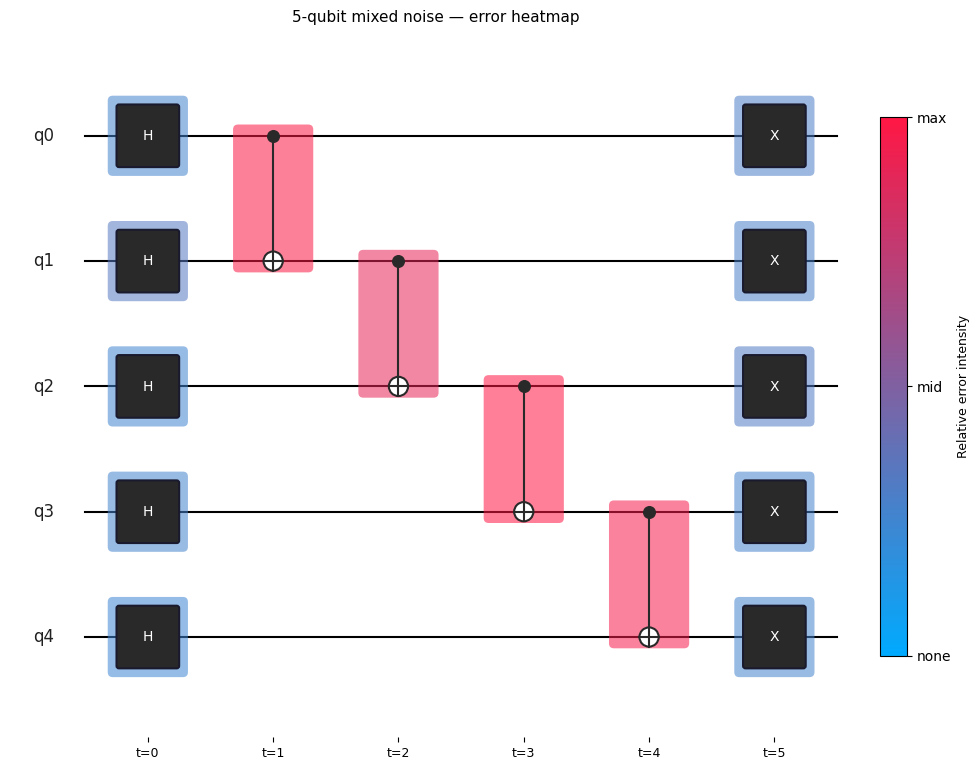

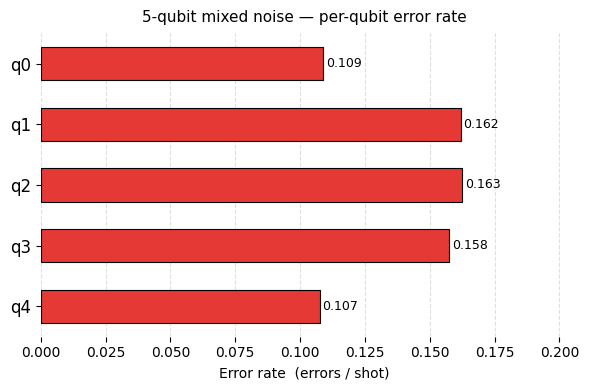


Total error events: 1397 across 2000 shots
Mean error rate per (qubit, gate) cell: 0.0100


In [2]:
# 5-qubit circuit: H layer (t=0), CNOT chain (t=1), X layer (t=2)
from noisiq.ir import Circuit, gates
from noisiq.noise import DepolarizingChannel, DephaseChannel
from noisiq.visualization import plot_error_heatmap, plot_qubit_error_bar
from noisiq.backends import ManyShotRunner


# Two ways of writing a circuit

# Method one :
# c5 = Circuit(n_qubits=5, name="five_qubit_mixed")
# for q in range(5):
#     c5.add_gate(gates.H, (q,))
# for q in range(4):
#     c5.add_gate(gates.CNOT, (q, q + 1))
# for q in range(5):
#     c5.add_gate(gates.X, (q,), t=5)

# Method Two :
c5 = (
    Circuit(5, name = "five_qubit_mixed")
    .h(0).h(1).h(2).h(3).h(4)
    .cnot(0, 1).cnot(1, 2).cnot(2, 3).cnot(3, 4)
    .x(0, t=5).x(1, t=5).x(2, t=5).x(3, t=5).x(4, t=5)
)

# Mixed noise: depolarizing on H and X, dephasing on CNOTs
noise_map = {}
for i, op in enumerate(c5.operations):
    if op.gate.name.upper() in ("H", "X"):
        noise_map[i] = DepolarizingChannel(p=0.03).to_pauli_error()
    elif op.gate.name.upper() == "CNOT":
        noise_map[i] = DephaseChannel(p=0.05).to_pauli_error()

runner = ManyShotRunner()
result5 = runner.run(c5, n_shots=2000, noise_config=noise_map, seed=42)

# — Heatmap (figsize auto-computed from circuit dimensions)
plot_error_heatmap(result5, c5, title="5-qubit mixed noise — error heatmap")
plt.show()

# — Per-qubit bar
plot_qubit_error_bar(result5, title="5-qubit mixed noise — per-qubit error rate")
plt.show()

print(f"\nTotal error events: {result5.counts_matrix.sum()} across {result5.n_shots} shots")
print(f"Mean error rate per (qubit, gate) cell: {result5.error_rate_matrix.mean():.4f}")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from noisiq.ir import Circuit, gates
from noisiq.noise import depolarizing_error, bit_flip_error
from noisiq.visualization import Visualizer

vis = Visualizer(c5)
vis.simulate(noise_config=noise_map, seed=42)
vis.show()
